<a href="https://colab.research.google.com/github/wjdwogns2873-web/deep-learning-study/blob/main/Kaggle_Study/14_PetFinder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
제미나이의 도움을 받아 작성한 코드입니다.
```



In [3]:
# 1. 구글 드라이브 연결 (로그인 팝업이 뜨면 확인만 눌러주세요)
from google.colab import drive
drive.mount('/content/drive')

# 2. 구글 드라이브에 저장해둔 열쇠(access_token)를 코랩 보안 폴더로 자동 복사
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle/access_token ~/.kaggle/
!chmod 600 ~/.kaggle/access_token

Mounted at /content/drive


In [4]:
!kaggle competitions download -c petfinder-adoption-prediction

100% 1.94G/1.94G [00:17<00:00, 117MB/s]



In [5]:
!unzip -q petfinder-adoption-prediction.zip -d ./data

In [6]:
!ls ./data

breed_labels.csv	   PetFinder-StateLabels.csv  test_sentiment
BreedLabels.csv		   state_labels.csv	      train
color_labels.csv	   StateLabels.csv	      train_images
ColorLabels.csv		   test			      train_metadata
PetFinder-BreedLabels.csv  test_images		      train_sentiment
PetFinder-ColorLabels.csv  test_metadata


In [7]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# 원본 경로 설정
IMAGE_DIR = './data/train_images'
CSV_PATH = './data/train/train.csv'

# 다운로드된 데이터 읽기
df = pd.read_csv(CSV_PATH)
# print(df.head())

# 용량이 매우 크기 때문에 다이어트용 새 폴더 생성
subset_img_dir = './train_images_subset'
os.makedirs(subset_img_dir, exist_ok=True)

# train_images 폴더에 실제로 존재하는 파일 이름들 가져오기
existing_images = os.listdir(IMAGE_DIR)
existing_pet_ids = {img.split('-')[0] for img in existing_images} # PetID 추출

# csv 데이터 중 실제 이미지가 존재하는 데이터만 필터링
df_filtered = df[df['PetID'].isin(existing_pet_ids)].reset_index(drop=True)

# 딱 1000개의 PetID만 샘플링
sample_size = 1000
df_subset = df_filtered.sample(n=min(sample_size, len(df_filtered)), random_state=42).reset_index(drop=True)

copied_count = 0

# 샘플링된 PetID에 해당하는 이미지들만 새 폴더로 복사
for pet_id in tqdm(df_subset['PetID']):
    # 한 PetID당 여러 장의 이미지(PetID-1.jpg, PetID-2.jpg)가 있을 수 있으므로 모두 복사
    matching_images = [img for img in existing_images if img.startswith(pet_id)]

    for img_name in matching_images:
        src = os.path.join(IMAGE_DIR, img_name)
        dst = os.path.join(subset_img_dir, img_name)
        shutil.copy(src, dst)
        copied_count += 1

# 샘플링된 결과 csv 저장
df_subset.to_csv('train_subset.csv', index=False)

print(f"매핑된 유기동물 수: {len(df_subset)}마리")
print(f"복사된 총 이미지 수: {copied_count}장")
print(f"새로 생성된 csv: train_subset.csv")

100%|██████████| 1000/1000 [00:07<00:00, 134.48it/s]

매핑된 유기동물 수: 1000마리
복사된 총 이미지 수: 4025장
새로 생성된 csv: train_subset.csv


In [8]:
train_subset = pd.read_csv('./train_subset.csv')
print(train_subset.head())

   Type                Name  Age  Breed1  Breed2  Gender  Color1  Color2  \
0     2              Munchi    1      15       0       1       1       7   
1     1                 NaN    2     307      78       3       1       2   
2     1  Gorilla & Daschund    1     307       0       2       1       2   
3     2               Datin   24     266       0       2       1       2   
4     2          California   24     254     266       2       3       6   

   Color3  MaturitySize  ...  Health  Quantity  Fee  State  \
0       0             1  ...       1         1    0  41345   
1       7             2  ...       1         2  200  41326   
2       0             2  ...       1         2    0  41326   
3       7             3  ...       1         1    0  41401   
4       7             1  ...       1         1   50  41401   

                          RescuerID  VideoAmt  \
0  ec0c78ffa25dae7dffdb9669b9ac9e95         0   
1  2864803699884df90ac135583b02ec70         0   
2  f45d8c72a87f27427cd2

In [9]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import pandas as pd

# 이미지 전처리(Transform) 정의
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ResNet 국룰 가중치
])

# PetFinder 커스텀 데이터셋 클래스 정의
class PetFinderRegressionDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pet_id = row['PetID']

        # 타겟 값(AdoptionSpeed)을 '실수형 텐서'로 변환 (회귀 모델의 핵심)
        # PyTorch 회귀 손실함수는 정밀한 계산을 위해 float32 타입을 요구합니다.
        target = torch.tensor([float(row['AdoptionSpeed'])], dtype=torch.float32)

        # 해당 PetID의 첫 번째 이미지 파일 경로 지정
        # (예: 'pet_id-1.jpg' 파일이 있으면 그것을 쓰고, 없으면 폴더 내 첫 번째 매칭 이미지를 찾음)
        img_path = os.path.join(self.img_dir, img_name)

        # 만약 -1.jpg가 어떤 이유로 유실되었다면 예외처리로 다른 장을 가져옴
        if not os.path.exists(img_path):
            all_imgs = [f for f in os.listdir(self.img_dir) if f.startswith(pet_id)]
            img_path = os.path.join(self.img_dir, all_imgs[0]) if all_imgs else None

        # 이미지 로드 및 전처리 적용
        if img_path:
            image = Image.open(img_path).convert('RGB')
        else:
            # 예외 상황용 더미 이미지 생성
            image = Image.new('RGB', (224, 224), color='white')

        if self.transform:
            image = self.transform(image)

        return image, target

IMG_SUBSET_DIR = './train_images_subset'
CSV_SUBSET_PATH = './train_subset.csv'

dataset = PetFinderRegressionDataset(csv_file=CSV_SUBSET_PATH, img_dir=IMG_SUBSET_DIR, transform=train_transform)

data_loader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

In [10]:
images, targets = next(iter(data_loader))

print(images.shape)
print(targets.shape)
print(targets[:5])

torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
tensor([[4.],
        [4.],
        [2.],
        [4.],
        [4.]])


In [11]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

class PetAdoptionRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. 이미 검증된 이미지 특징 추출기(ResNet18) 로드
        self.backbone = models.resnet18(pretrained=True)

        # 2. 오리지널 ResNet18의 최종 출력 피처 개수(512) 확보
        in_features = self.backbone.fc.in_features

        # 3. 마지막 레이어를 회귀(Regression) 목적에 맞게 재조립
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2), # 오버피팅 방지용 안전장치
            nn.Linear(128, 1) # 최종 예측 결과물: 단 1개의 실수 (AdoptionSpeed 예측값)
        )

    def forward(self, x):
        return self.backbone(x)

model = PetAdoptionRegressor().to(device)

device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


In [12]:
import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
import time

epochs = 3

for epoch in range(epochs):
    start_time = time.time()
    model.train()

    running_loss = 0.0
    batch_count = 0
    for images, targets in data_loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        batch_count += 1

    epoch_loss = running_loss / (batch_count * 32)
    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{epochs}] {epoch_time:.1f}초 - Train Loss (MSE): {epoch_loss:.4f}")

Epoch [1/3] 8.2초 - Train Loss (MSE): 1.8943
Epoch [2/3] 5.8초 - Train Loss (MSE): 1.3958
Epoch [3/3] 6.5초 - Train Loss (MSE): 1.3992


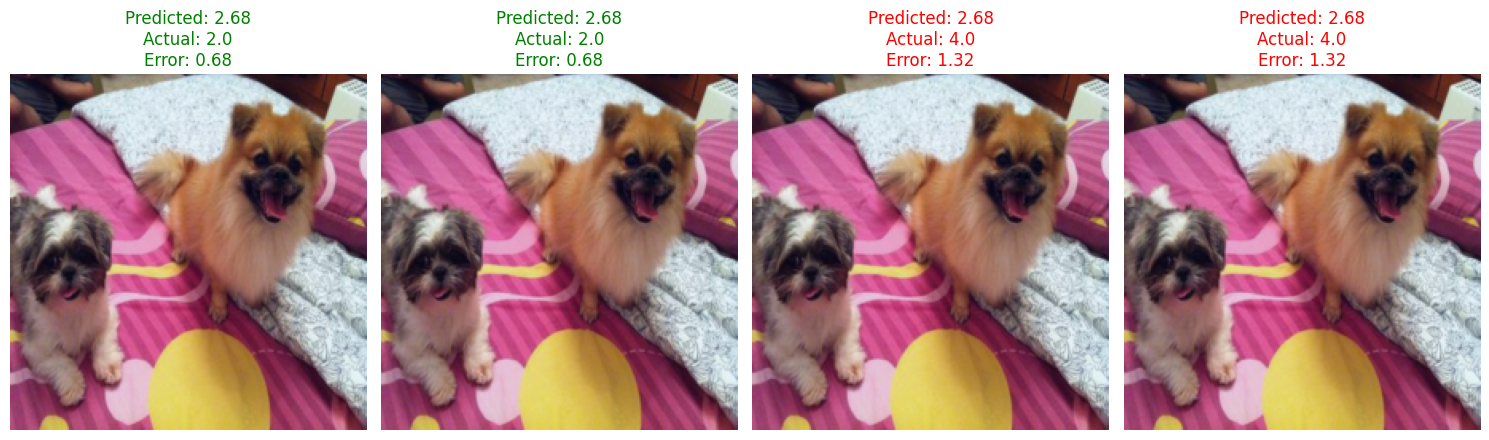

In [16]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

images, targets = next(iter(data_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    predictions = outputs.cpu().numpy()
    actuals = targets.numpy()

plt.figure(figsize=(15, 10))

for i in range(4):
    plt.subplot(1, 4, i + 1)

    # 파이토치 텐서 이미지(C, H, W)를 matplotlib 포맷(H, W, C)로 복원
    # 역정규화를 간단히 처리하여 이미지 픽셀값을 0~1로 맞춤
    img = images[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    # 소숫점 둘째 자리까지 이쁘게 포맷팅
    pred_val = predictions[i][0]
    true_val = actuals[i][0]

    error = abs(pred_val - true_val)

    plt.title(f"Predicted: {pred_val:.2f}\nActual: {true_val:.1f}\nError: {error:.2f}",
              color='red' if error > 1.0 else 'green', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()